In [48]:
import torch
from dinosaw.models.vit_wrapper import MODEL_LIST, PretrainedViTWrapper, AlibiVitWrapper
from dinosaw.utils import do_2D_pca, to_numpy, closest_resize, convert_image

import numpy as np

from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib import font_manager

CLASSICAL_AVAILABLE = True
try:
    from interactive_seg_backend import featurise, FeatureConfig, TrainingConfig
except ImportError:
    CLASSICAL_AVAILABLE = False



SEED = 100001
torch.manual_seed(SEED)
np.random.seed(SEED)

In [49]:
alibi_model = AlibiVitWrapper(
    MODEL_LIST[1],
    stride=14,
    add_flash_attn=False,
    device="cuda:0",
    slope_type="constant",
    normalize=True,
    wrap=True,
)

weights = torch.load("../../trained_models/alibi_dv2_vits14_reg.pth", weights_only=True, map_location="cuda:0")
alibi_model.load_state_dict(weights)
alibi_model.eval()
None

In [50]:
dv2_model = PretrainedViTWrapper(
    MODEL_LIST[1],
    stride=14,
    add_flash_attn=False,
    device="cuda:0",
)

dv2_model.eval()
None

In [51]:
def get_features(model: PretrainedViTWrapper, pil_img: Image.Image) -> np.ndarray:
    tr = closest_resize(pil_img.height, pil_img.width, 14)
    img_tensor = convert_image(pil_img, tr, device_str="cuda:0", to_half=False)
    with torch.no_grad():
        emb = model.forward_features(img_tensor, make_2D=True)
    emb_np = to_numpy(emb.squeeze(0))
    return emb_np


def get_classical_features(pil_img: Image.Image) -> np.ndarray:
    img_arr = np.array(pil_img)
    f_cfg = FeatureConfig(hessian_filter=False, membrane_projections=False, difference_of_gaussians=False)
    t_cfg = TrainingConfig(feature_config=f_cfg)
    emb_np = featurise(img_arr, t_cfg)
    return emb_np

In [52]:

def add_custom_font(font_folder: str, font_name: str="Grotesk") -> None:
    try:
        font_paths = (f'{font_folder}/{font_name}.ttf', f'{font_folder}/{font_name}-Bold.ttf')
        for font_path in font_paths:
            font_manager.fontManager.addfont(font_path)
        prop = font_manager.FontProperties(fname=font_paths[0])

        plt.rcParams['font.family'] = 'sans-serif'
        plt.rcParams['font.sans-serif'] = prop.get_name()
    except Exception as e:
        print(f"Can't load custom font: {e} ")


def make_figure(n_rows: int, n_angles: int, show_img: bool, n_spacer_rows: int=1, rel_spacer_w: float=0.2, n_models: int = 2) -> tuple[plt.Figure, GridSpec]:
    n_cols = n_angles + (2 if show_img else 0)

    rel_heights = [1 for _ in range(n_rows + n_spacer_rows)]
    for i in range(n_spacer_rows):
        rel_heights[n_models* (i + 1) + i // n_models] = rel_spacer_w

    fig = plt.figure(figsize=(4 * n_cols, 3 * (n_rows + n_spacer_rows)))
    gs = GridSpec(n_rows + n_spacer_rows, n_cols, figure=fig, height_ratios=rel_heights)

    return fig, gs


def get_axes_row(fig, gs, row_idx: int, n_angles: int=5, show_img: bool=True, n_spacer_rows: int=1, n_models: int = 2) -> list[plt.Axes]:
    axs = []
    col = 0

    offset = (row_idx // n_models)  * n_spacer_rows
    row_idx += offset

    if show_img:
        for _ in range(2):
            ax = fig.add_subplot(gs[row_idx, col])
            axs.append(ax)
            col += 1

    for _ in range(n_angles):
        ax = fig.add_subplot(gs[row_idx, col], projection='3d')
        axs.append(ax)
        col += 1

    return axs

def hide_axes(ax: plt.Axes):
    ax.set_xticks([])
    ax.set_yticks([])
    if hasattr(ax, 'set_zticks'):
        ax.set_zticks([])

def plot_row_of_embeddings(image: Image.Image, emb_2D: np.ndarray, axs: list[plt.Axes], n_angles: int=5, show_img: bool=True):
    if show_img:
        axs[0].imshow(image)
        hide_axes(axs[0])
        axs[1].imshow(emb_2D)
        hide_axes(axs[1])


    col_offset = 2 if show_img else 0

    for i in range(col_offset, n_angles + col_offset):
        ax = axs[i]

        j = i - col_offset
        angle_deg = 270 + j * (180 // n_angles)

        ax.view_init(azim=angle_deg)

        embed_flat = emb_2D.reshape(-1, 3)

        xs = embed_flat[:, 0] - 0.5
        ys = embed_flat[:, 1] - 0.5
        zs = embed_flat[:, 2] - 0.5

        colours = embed_flat
        ax.scatter(xs, ys, zs, marker='o', c=colours, s=10, alpha=0.6)

        hide_axes(ax)
    return 

In [53]:
image_names = ["diff_shapes_518.png", "snowcat.png"]
models = [dv2_model, alibi_model]
titles = ["DINOv2", "ALiBi-Dv2"]

In [54]:
embeddings = []
ADD_CLASSICAL = False

for img_fname in image_names:
    for model in models:
        _img = Image.open(f"data/3D_plot/{img_fname}").convert("RGB")
        _img = _img.resize((518, 518))

        if model == 'weka' and CLASSICAL_AVAILABLE and ADD_CLASSICAL:
            emb_np = get_classical_features(_img)
            emb_np =  emb_np.transpose(2, 0, 1)
        elif model == "weka":
            continue
        else:
            emb_np = get_features(model, _img)
        
        pca_emb = do_2D_pca(emb_np, n_components=3, pre_norm='std', post_norm="minmax")
        embeddings.append(pca_emb)

GridSpec(5, 5, height_ratios=[1, 1, 0.2, 1, 1])


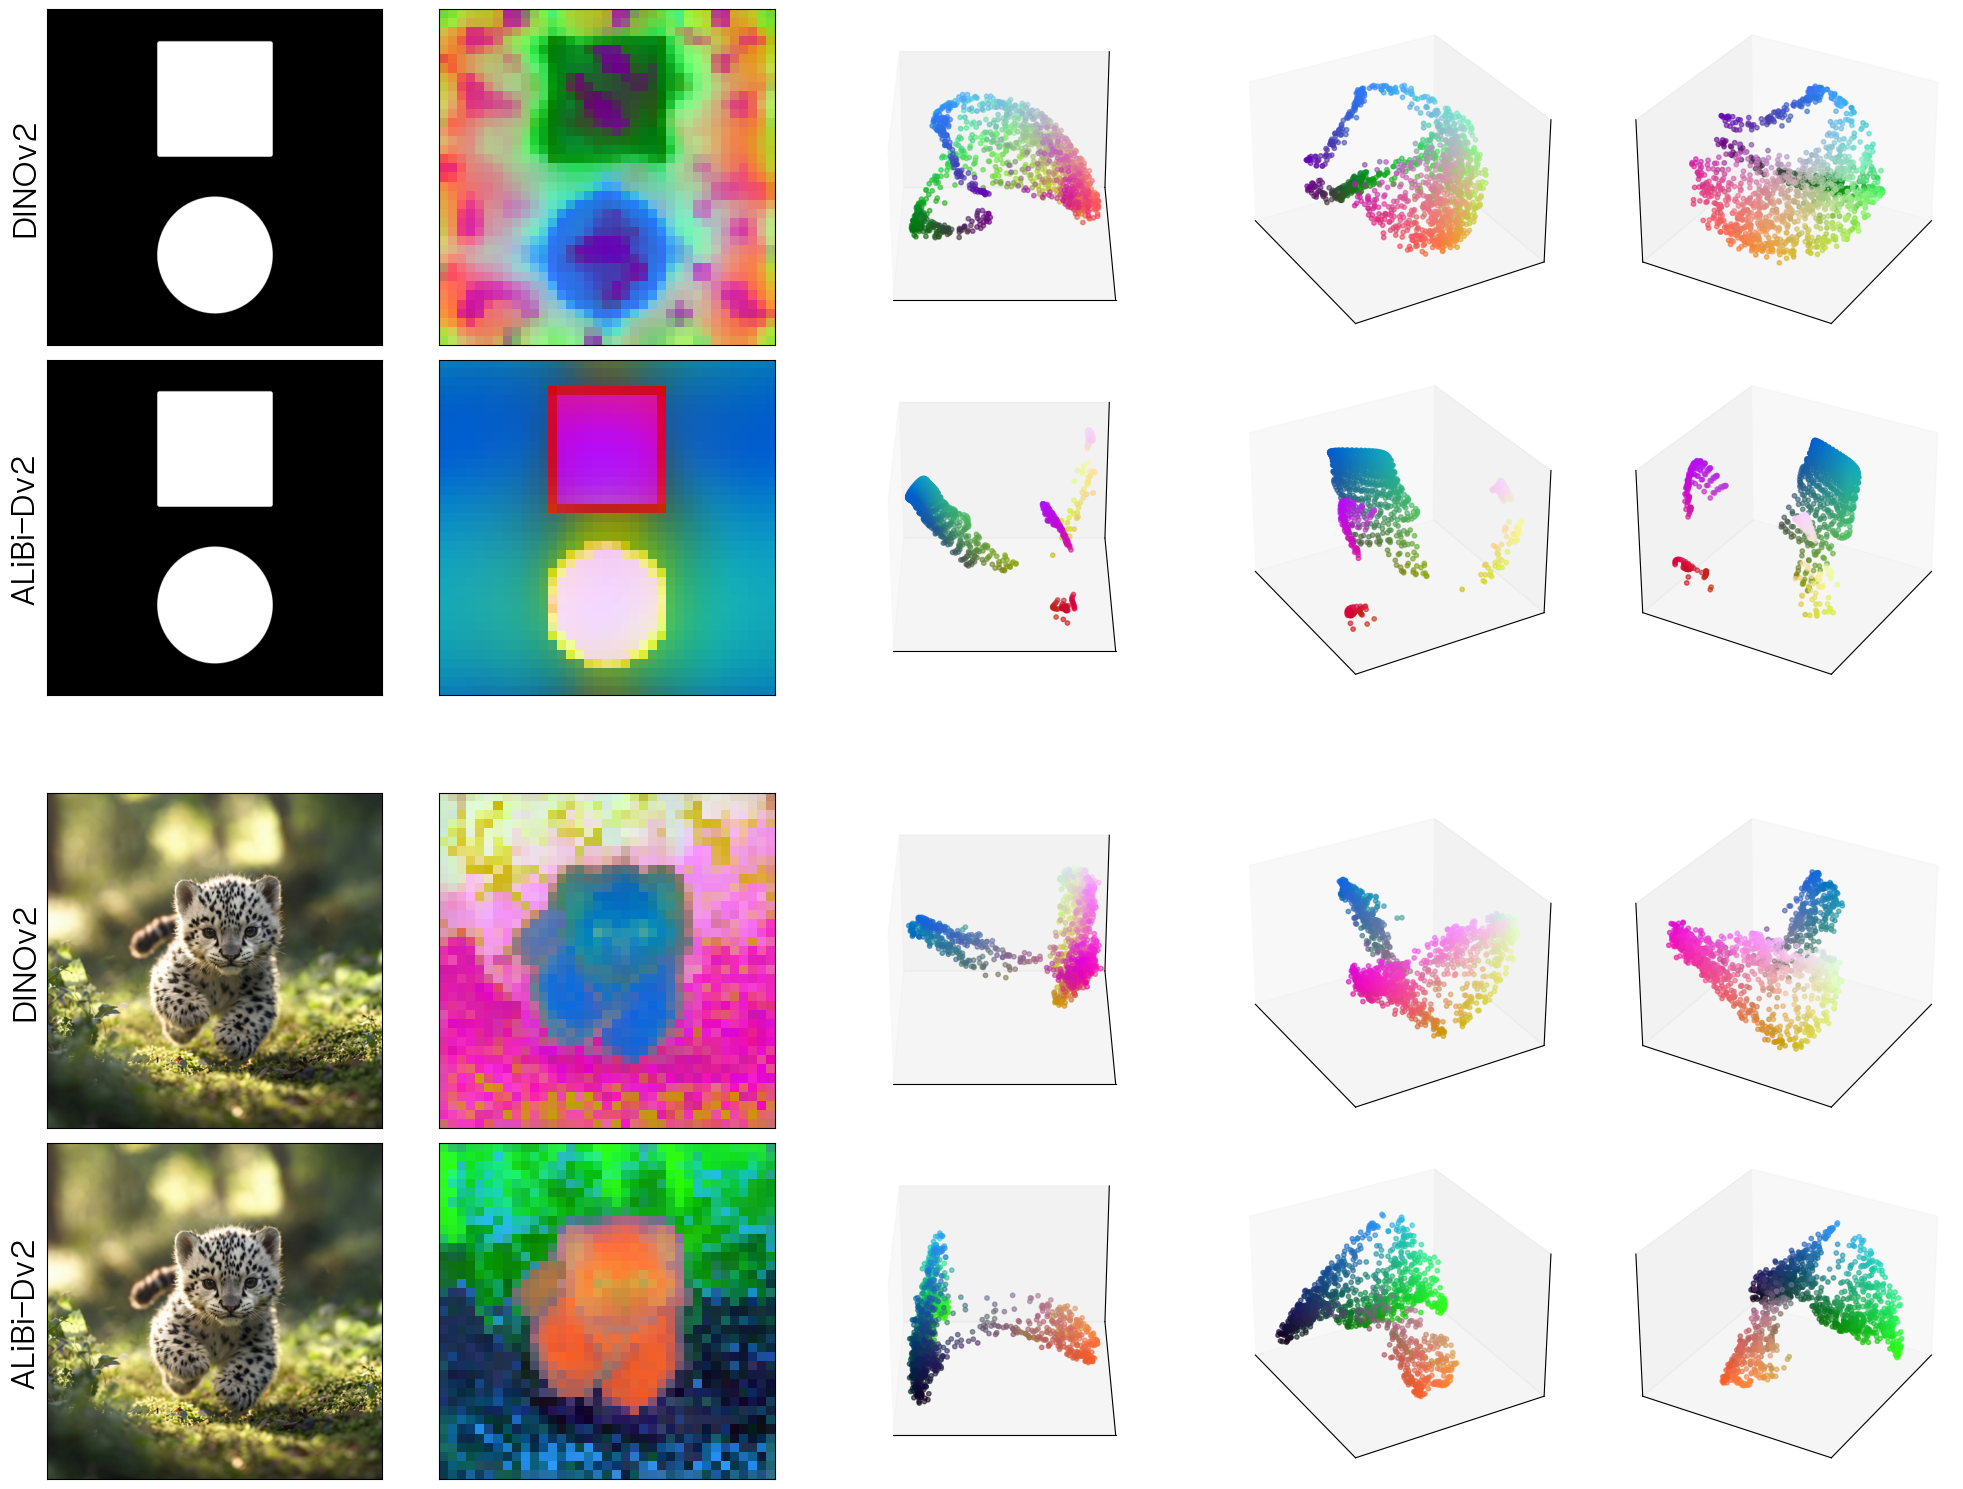

In [ ]:
%%capture
add_custom_font('resources/fonts', 'Grotesk')
n_rows = len(image_names) * len(models)  # 2 models per image
n_angles = 3


n_spacer_rows = 1

fig, gs = make_figure(n_rows=n_rows, n_angles=n_angles, show_img=True, n_spacer_rows=n_spacer_rows, rel_spacer_w=0.2, n_models=len(models))
print(gs)

j = 0
for img_fname in image_names:
    for title, model in zip(titles, models):
        _img = Image.open(f"data/3D_plot/{img_fname}").convert("RGB")
        _img = _img.resize((518, 518))

        emb = embeddings[j]

        axs = get_axes_row(fig, gs, j, n_angles=n_angles, show_img=True, n_spacer_rows=n_spacer_rows, n_models=len(models))
        axs[0].set_ylabel(f"{title}", fontsize=24, fontweight=500)
        plot_row_of_embeddings(_img, emb, axs, n_angles=n_angles, show_img=True)

        j += 1


plt.tight_layout()
plt.savefig('saved/pca_and_3D_plots.png', dpi=300)